The objective of this exercise is the ability to predict person's body type and its obesity level based on certain criteria like Age, Gender, Height, weight, BMI and physical activity level. The prediction will classify the person to one of these categories; Normal Weight, Obese, Overweight, Underweight

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import category_encoders as ce

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, precision_recall_curve, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [2]:
# loading the data and checking the first 5 rows and the data types of each column
obesity = pd.read_csv('data/obesity.csv')
print(obesity.head())
print('==========================================================================')
print(obesity .info())
print('==========================================================================')


   Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
0   56    Male  173.575262  71.982051  23.891783                      4   
1   69    Male  164.127306  89.959256  33.395209                      2   
2   46  Female  168.072202  72.930629  25.817737                      4   
3   32    Male  168.459633  84.886912  29.912247                      3   
4   60    Male  183.568568  69.038945  20.487903                      3   

  ObesityCategory  
0   Normal weight  
1           Obese  
2      Overweight  
3      Overweight  
4   Normal weight  
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Gender                 1000 non-null   str    
 2   Height                 1000 non-null   float64
 3   Weight                 1000 non-null   float64
 4   BMI               

In [3]:
# investigating missing data
print(obesity.isnull().sum())

Age                      0
Gender                   0
Height                   0
Weight                   0
BMI                      0
PhysicalActivityLevel    0
ObesityCategory          0
dtype: int64


ObesityCategory
Normal weight    371
Overweight       295
Obese            191
Underweight      143
Name: count, dtype: int64


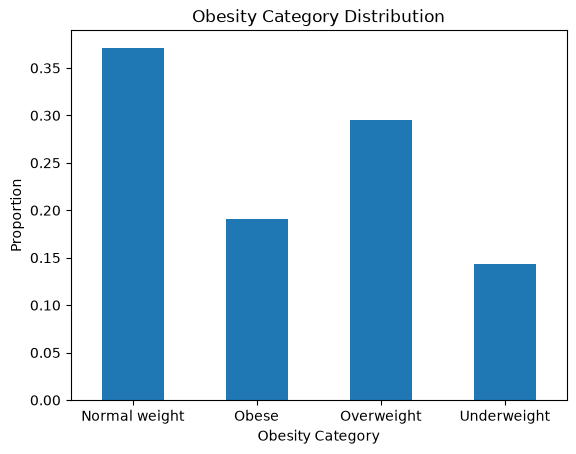

In [4]:
# Visualizing the distribution of the target variable

print(obesity.value_counts('ObesityCategory', dropna=False))

obesity['ObesityCategory'].value_counts(normalize=True).sort_index().plot(kind='bar')
plt.title('Obesity Category Distribution')
plt.xlabel('Obesity Category')
plt.ylabel('Proportion')
plt.xticks([0, 1, 2, 3], ['Normal weight','Obese','Overweight','Underweight'], rotation=0)
plt.show()

<Axes: xlabel='BMI', ylabel='ObesityCategory'>

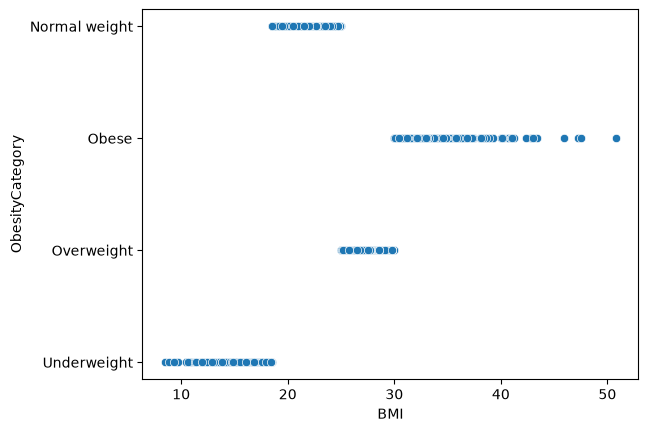

In [5]:
 # working with Age target data 
sns.scatterplot(data=obesity, x='BMI', y='ObesityCategory')

<Axes: xlabel='Weight', ylabel='ObesityCategory'>

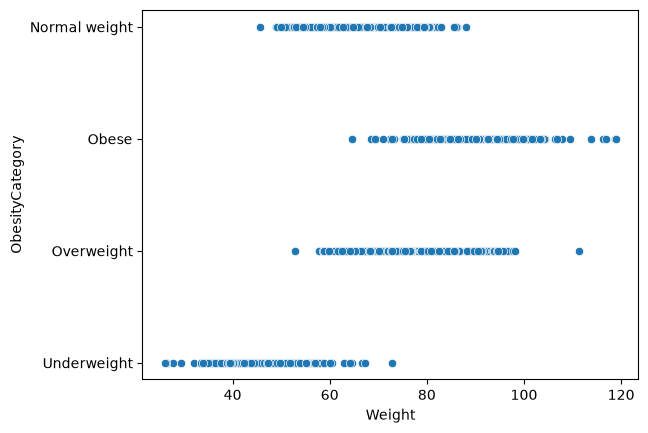

In [6]:
# working with Age target data 
sns.scatterplot(data=obesity, x='Weight', y='ObesityCategory')

From the above graph we notice that the target is not totally balanced and threfore i will be looking at f1 and ROC in addition to the accuracy score to determine the performance of the model.

In [7]:
# Splitting the data into training and testing sets

X = obesity.drop(columns=['ObesityCategory'])
y = obesity['ObesityCategory']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size=0.33, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print('==========================================================================')
print(y_train.head())
print('==========================================================================')
print(X_train.head())

(670, 6) (330, 6) (670,) (330,)
451       Overweight
283            Obese
20     Normal weight
979    Normal weight
771       Overweight
Name: ObesityCategory, dtype: str
     Age  Gender      Height     Weight        BMI  PhysicalActivityLevel
451   22    Male  172.515711  85.509449  28.731401                      4
283   66    Male  163.422272  81.828229  30.639429                      4
20    39  Female  182.301613  72.900937  21.935730                      4
979   68    Male  165.304478  53.108621  19.435503                      2
771   66  Female  163.073384  70.511980  26.515312                      1


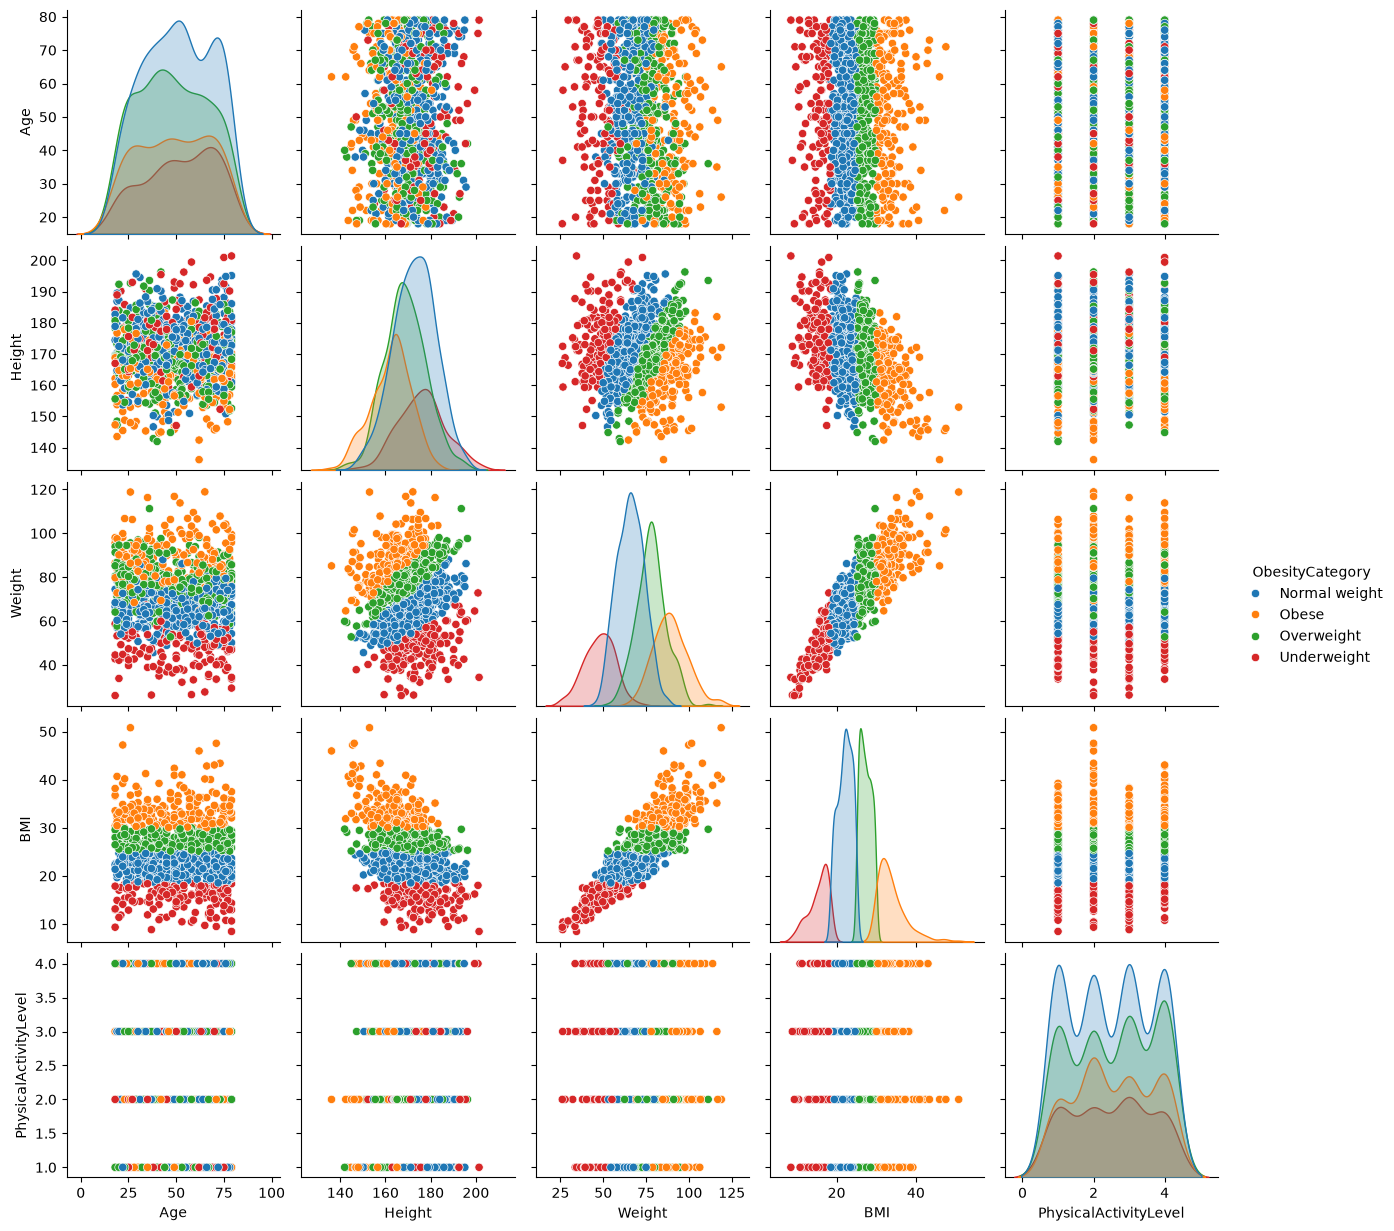

In [8]:
sns.pairplot(obesity, hue="ObesityCategory", diag_kind='kde')
plt.show()

In [9]:
#encoding categorical variables using one-hot encoding
encoder = ce.OrdinalEncoder(cols=['Gender'])
X_train = encoder.fit_transform(X_train)
X_test = encoder.fit_transform(X_test)

print(X_train.head())

     Age  Gender      Height     Weight        BMI  PhysicalActivityLevel
451   22       1  172.515711  85.509449  28.731401                      4
283   66       1  163.422272  81.828229  30.639429                      4
20    39       2  182.301613  72.900937  21.935730                      4
979   68       1  165.304478  53.108621  19.435503                      2
771   66       2  163.073384  70.511980  26.515312                      1


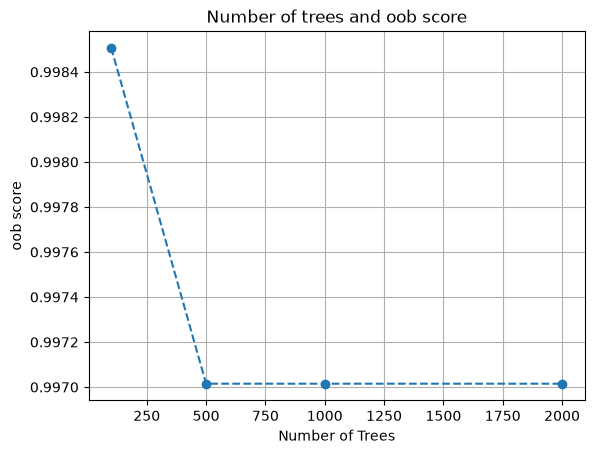

In [10]:
# I am just going to use the Random Forest Classifier for this project. I will use the out-of-bag score to evaluate the model. I will also use the feature importances to select the most important features for the model.
n_trees = [100, 500, 1000, 2000]
oob_scores = []
for i in n_trees:
    forest = RandomForestClassifier(oob_score= True, random_state=42, n_estimators=i).fit(X_train,y_train)
    oob_scores.append(forest.oob_score_)

plt.plot(n_trees, oob_scores, '--o')
plt.grid()
plt.title('Number of trees and oob score')
plt.xlabel('Number of Trees')
plt.ylabel("oob score");

In [11]:
# Random Forest with 500 trees and out-of-bag score
forest = RandomForestClassifier(oob_score= True, random_state=42, n_estimators=500).fit(X_train,y_train)
y_pred = forest.predict(X_test)

print('Random ForestAccuracy:', accuracy_score(y_test, y_pred))




Random ForestAccuracy: 0.9939393939393939


In [12]:
# identify feature scores
feature_scores = pd.Series(forest.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feature_scores)


BMI                      0.663555
Weight                   0.227796
Height                   0.082267
Age                      0.017836
PhysicalActivityLevel    0.005394
Gender                   0.003152
dtype: float64


In [13]:
# we can see that the most important features are BMI, Weight. We can use this information to select the most important features for our model.
X_reduced_train = X_train[['BMI', 'Weight']]
X_reduced_test = X_test[['BMI', 'Weight']]

forest = RandomForestClassifier(oob_score= True, random_state=42, n_estimators=500).fit(X_reduced_train,y_train)
y_pred = forest.predict(X_reduced_test)
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred))
print("================================")

print('Random Forest OOB Score:', forest.oob_score_)
print("===============================")
report = classification_report(y_test, y_pred)
print(report)   
confusion_matrix(y_test, y_pred)

Random Forest Accuracy: 0.996969696969697
Random Forest OOB Score: 0.9970149253731343
               precision    recall  f1-score   support

Normal weight       1.00      0.99      1.00       123
        Obese       1.00      1.00      1.00        63
   Overweight       1.00      1.00      1.00        97
  Underweight       0.98      1.00      0.99        47

     accuracy                           1.00       330
    macro avg       0.99      1.00      1.00       330
 weighted avg       1.00      1.00      1.00       330



array([[122,   0,   0,   1],
       [  0,  63,   0,   0],
       [  0,   0,  97,   0],
       [  0,   0,   0,  47]])

In [14]:
# this is just a prilimenary model testing to see which model performs best on the data. The models will be tuned later on.
# GridSearchCV going to be part of the model tuning process to find the best hyperparameters for each model.

final_results = {
    'Model':[],
    'Train Time':[],
    'Train Accuracy':[],
    'Test Accuracy':[],
    'Test Precision':[],
    'Test Recall':[],
    'Test f1':[],
}

finall_models = {
    'KNN':KNeighborsClassifier(n_neighbors = 49),
    'Logistic Regression': LogisticRegression(max_iter=10000,C=np.float64(4.281332398719396),l1_ratio= 0, solver= 'lbfgs'),
    'Decision Tree': DecisionTreeClassifier(criterion='entropy',max_depth=5,max_features=None,min_samples_leaf=1,min_samples_split=2),
    'SVM':SVC(C=1,gamma=0.01,kernel='rbf')
}


import time
for model_name, model in finall_models.items():
    start_time = time.time()
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipeline.fit(X_reduced_train, y_train)
    train_time = time.time() - start_time
    pred = pipeline.predict(X_reduced_test)
    final_results['Model'].append(model_name)
    final_results['Train Time'].append(train_time)
    final_results['Train Accuracy'].append(accuracy_score(y_train, pipeline.predict(X_reduced_train)))
    final_results['Test Accuracy'].append(accuracy_score(y_test, pred))
    final_results['Test Precision'].append(precision_score(y_test, pred, average='macro'))
    final_results['Test Recall'].append(recall_score(y_test, pred, average='macro'))
    final_results['Test f1'].append(f1_score(y_test, pred, average='macro'))

In [15]:
comparison_final = pd.DataFrame(final_results)
comparison_final.round(3)

,Model,Train Time,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test f1
0,KNN,0.002,0.931,0.885,0.909,0.865,0.883
1,Logistic Regression,0.007,0.970,0.970,0.978,0.968,0.973
2,Decision Tree,0.002,1.000,0.997,0.995,0.998,0.996
3,SVM,0.005,0.851,0.836,0.893,0.792,0.824
